# Notebook 01: Data Exploration

In [1]:
import colorcet
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from atomic_ocean_waves import mission_specifications, plotting

TODO:
- [x] time series
- [x] spectrograms
- [ ] incorporate apply_frequency_reduction_ufunc for all
- [ ] preprocessed and processed files?
- [ ] overall map + site maps

In [2]:
# Mission time periods
leg_1_time_start, leg_1_time_end = mission_specifications.leg_1_times
leg_2_time_start, leg_2_time_end = mission_specifications.leg_2_times
leg_1_longitudes, leg_1_latitudes = mission_specifications.leg_1_coordinates
leg_2_longitudes, leg_2_latitudes = mission_specifications.leg_2_coordinates

## Open datasets


Open datasets processed in the previous notebook.

In [3]:
swift_ds = xr.open_dataset('../data_processed/swift.nc')
wg_ds = xr.open_dataset('../data_processed/wave_glider.nc')
wg_ds = xr.open_dataset('../data_processed/wave_glider.nc')
wsra_ds = xr.open_dataset('../data_processed/wsra.nc')
p3_ds = xr.open_dataset('../data_processed/p3.nc')
sd_ds = xr.open_dataset('../data_processed/saildrone.nc')
ship_10min_ds = xr.open_dataset('../data_processed/ship_10min.nc')
riegl_ds = xr.open_dataset('../data_processed/riegl.nc')
ww3_ds = xr.open_dataset('../data_processed/ww3.nc')

In [4]:
# TODO: move to plotting
swift_color = 'goldenrod'
wg_color = 'crimson'
sd_color = 'teal'
p3_color = 'navy'
wsra_color = 'navy'
riegl_color = 'indigo'  # '#5C4033'
ship_color = 'indigo'
ww3_color = 'silver'

## Map

TODO: 
- [ ] map by mission leg
- [ ] use cartopy (projection)
- [ ] update background color/bathy/land

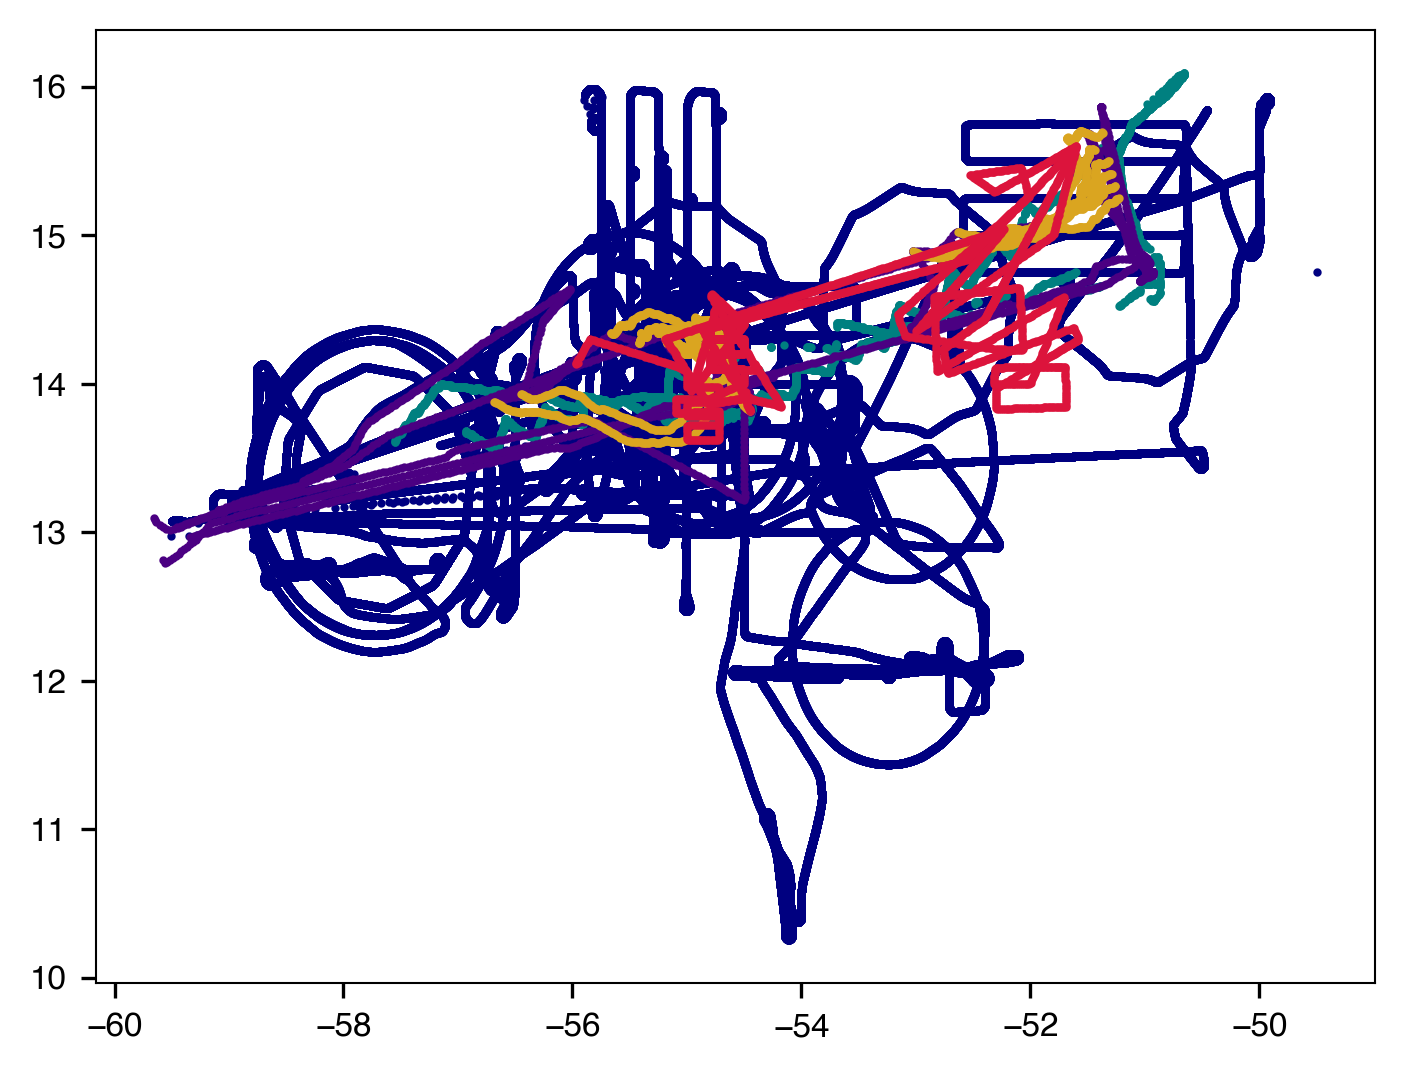

In [34]:
fig, ax = plt.subplots()


ax.scatter(
    p3_ds['lon'],
    p3_ds['lat'],
    color=p3_color,
    s=1,
)
ax.scatter(
    wsra_ds['longitude'],
    wsra_ds['latitude'],
    color=wsra_color,
    s=1,
)
ax.scatter(
    sd_ds['LON'],
    sd_ds['LAT'],
    color=sd_color,
    s=1,
)
ax.scatter(
    ship_10min_ds['lon'],
    ship_10min_ds['lat'],
    color=ship_color,
    s=1,
)
ax.scatter(
    swift_ds['lon'],
    swift_ds['lat'],
    color=swift_color,
    s=1,
)
ax.scatter(
    wg_ds['lon'],
    wg_ds['lat'],
    color=wg_color,
    s=1,
)

## Time series


TODO:
- [x] plot Hs
- [x] plot period
- [x] plot wave dir
- [x] plot wind dir
- [x] plot wind speed
- [x] plot WW3 (averages over domain)
- [ ] clean up wind, wave dir plots
- [ ] adjust all to U10?

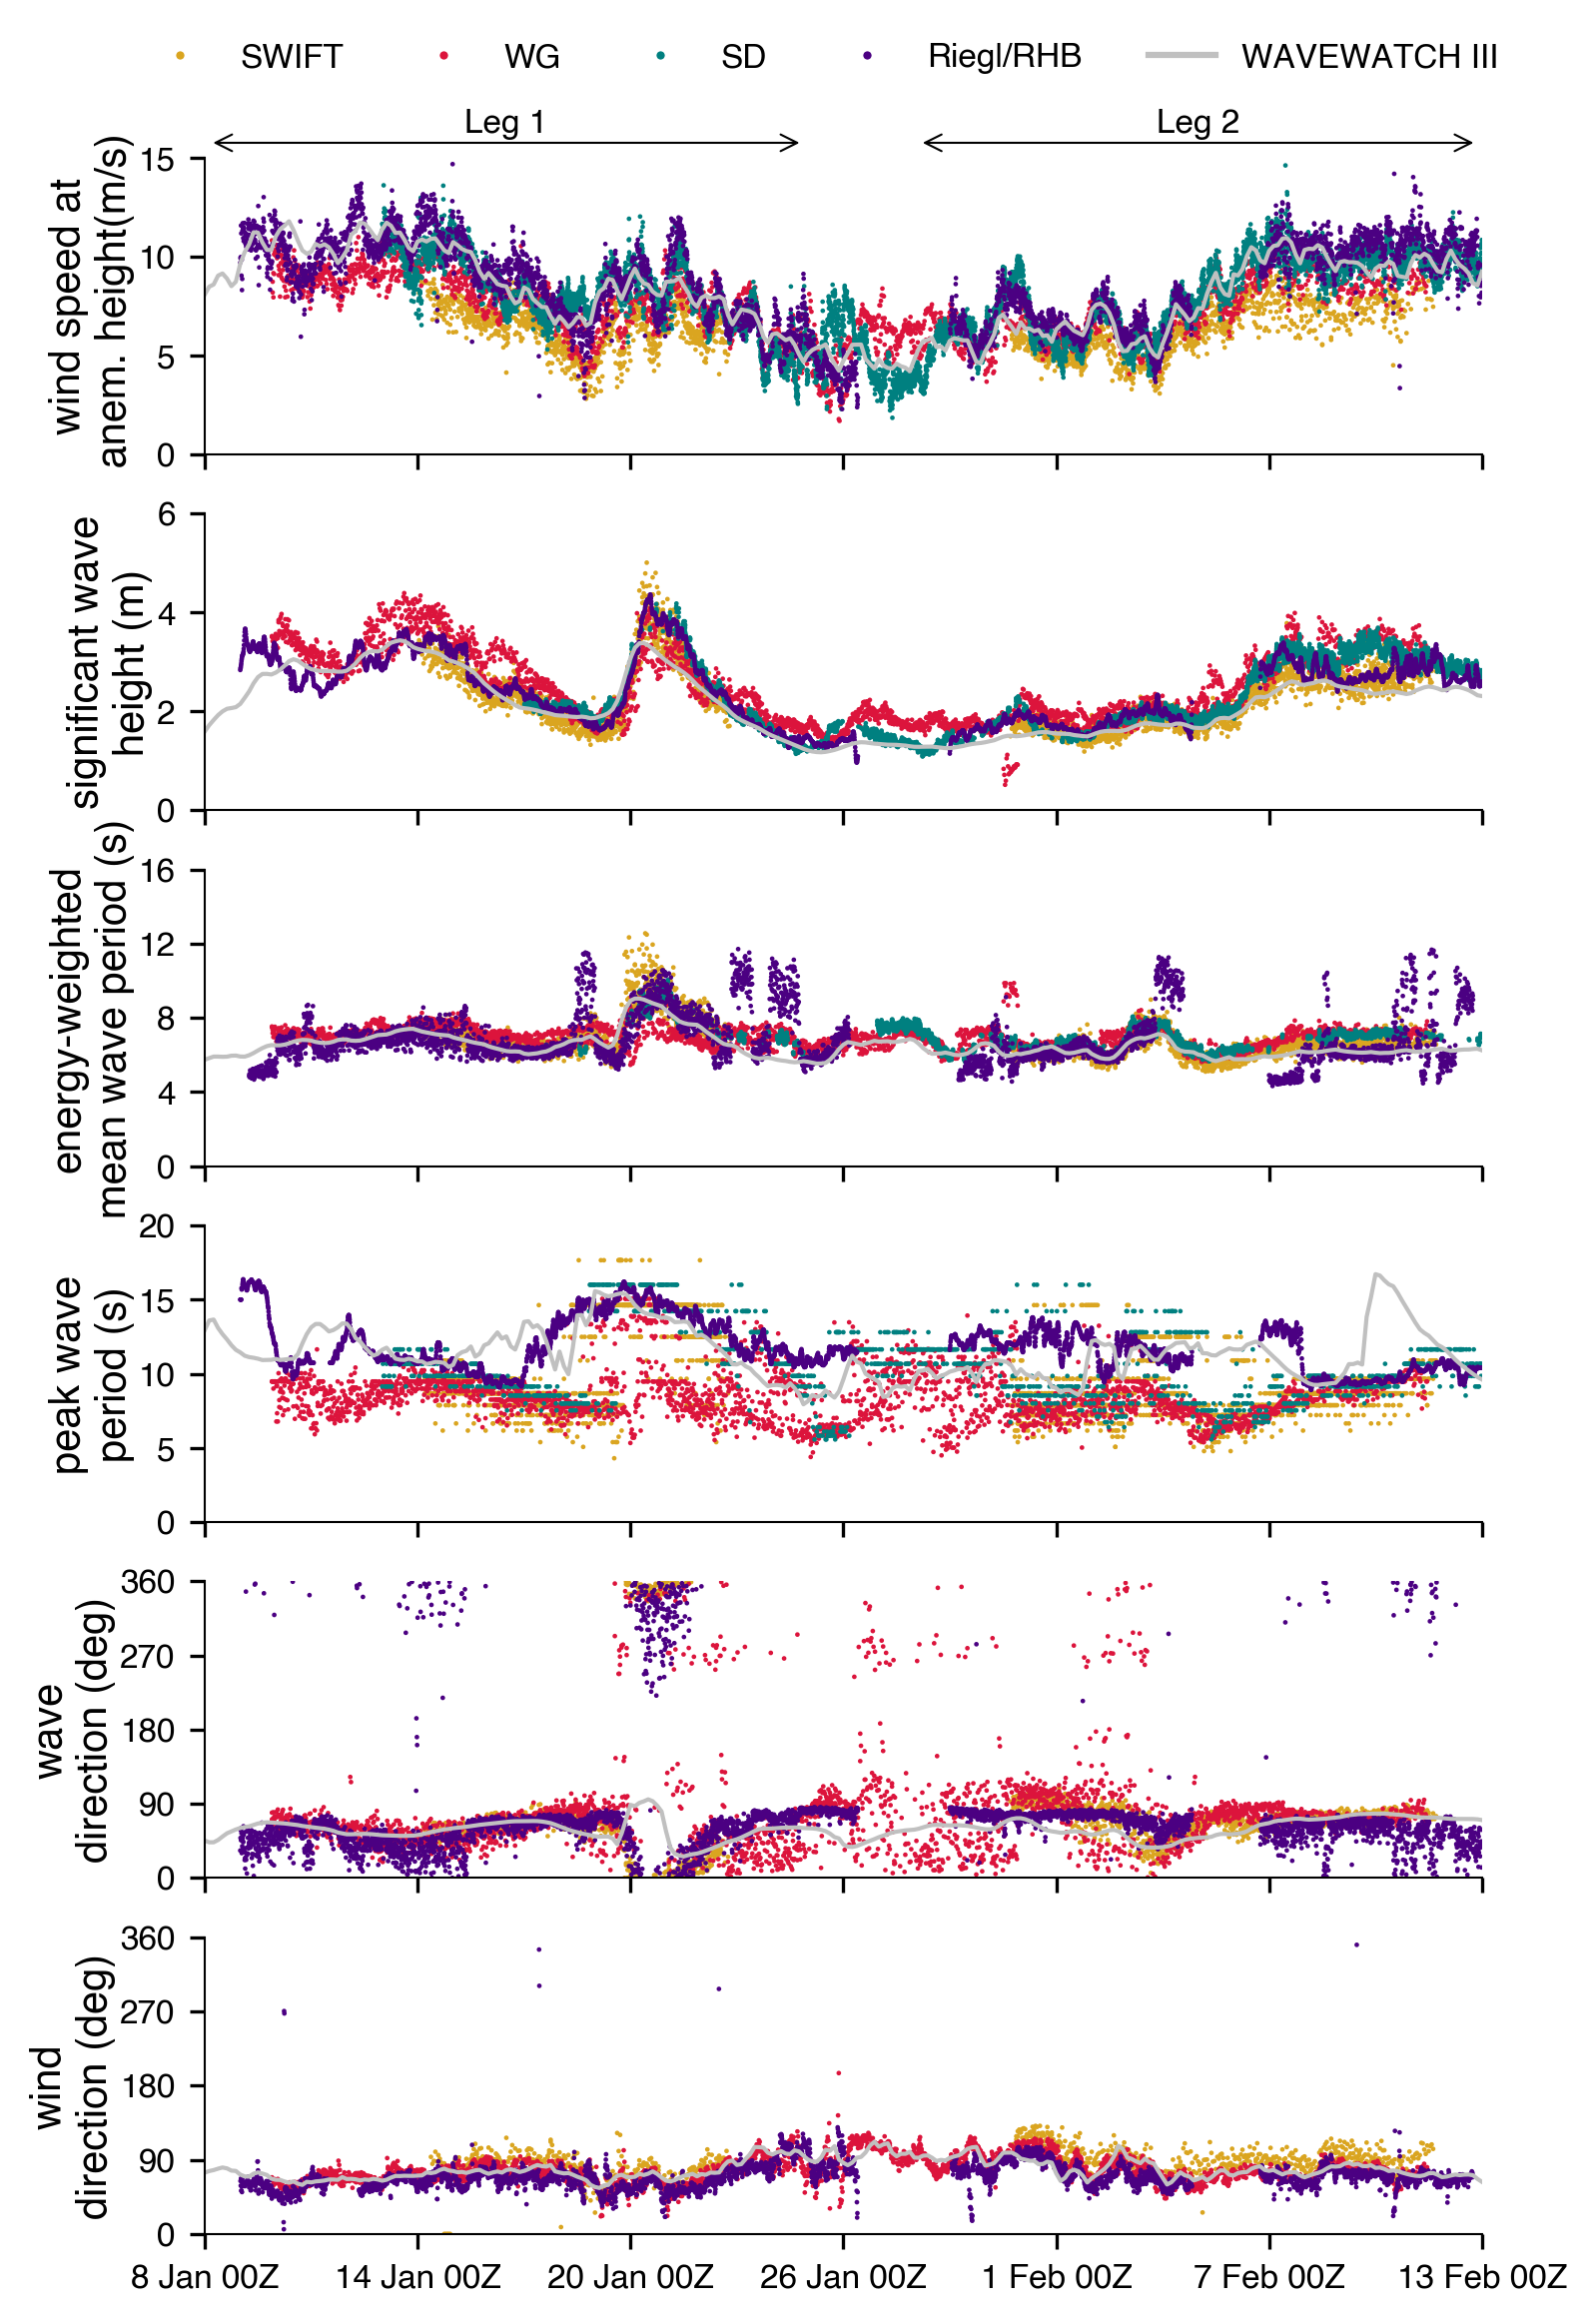

In [32]:
plot_time_start = pd.Timestamp('2020-01-08T00:00', tz='utc')
plot_time_end = pd.Timestamp('2020-02-13T00:00', tz='utc')

scatter_kwargs = {
    's': 5,
    'marker': '.',
    'edgecolor': 'none',
    # 'clip_on': False,
}
label_kwargs = {
    'loc': 'upper left',
    'nudge_x': -0.04,
    'nudge_y': 0.00
}

fig, axes = plt.subplots(
    nrows=6,
    ncols=1,
    sharex=True,
    figsize=(plotting.figure_full_width, 9)
)
labeler = plotting.SubplotLabeler()
axes_iter = plotting.axes_to_iterator(axes)

# Wind speed
ax = next(axes_iter)
for swift_id in swift_ds['id']:
    ax.scatter(
        swift_ds['time'],
        swift_ds.sel(id=swift_id)['wind_speed'],
        color=swift_color,
        label='SWIFT',
        **scatter_kwargs,
    )
for wg_id in wg_ds['id']:
    ax.scatter(
        wg_ds['time'],
        wg_ds.sel(id=wg_id)['wind_speed'],
        color=wg_color,
        label='WG',
        **scatter_kwargs,
    )
ax.scatter(
    sd_ds['TIME'],
    sd_ds['horizontal_wind_speed_mean'],
    color=sd_color,
    label='SD',
    **scatter_kwargs,
)
# TODO:
# ax.scatter(
#     wsra_ds['time'],
#     wsra_ds['sea_surface_wave_significant_height'],
#     color=wsra_color,
#     label='WSRA',
#     **scatter_kwargs,
# )
# TODO:
# ax.scatter(
#     p3_ds['time'],
#     p3_ds['U10_sfmr_corr'],
#     color=wsra_color,
#     label='P-3 SFMR',
# )
ax.scatter(
    ship_10min_ds['time'],
    ship_10min_ds['wspd_sfc'],
    color=ship_color,
    label='Riegl/RHB',
    **scatter_kwargs,
)
ax.plot(
    ww3_ds['time'],
    ww3_ds['wnd'].mean(('latitude', 'longitude')),
    color=ww3_color,
    label='WAVEWATCH III',
    linewidth=1,
    # **scatter_kwargs,
)

ax.set_ylim([0, 15])
ax.set_yticks(np.linspace(0, 15, 4))
ax.set_ylabel(
    'wind speed at\n anem. height(m/s)',
    labelpad=1,
    fontsize=plotting.normal_font_size
)


# Significant wave height
ax = next(axes_iter)
for swift_id in swift_ds['id']:
    ax.scatter(
        swift_ds['time'],
        swift_ds.sel(id=swift_id)['sea_surface_wave_significant_height'],
        color=swift_color,
        label='SWIFT',
        **scatter_kwargs,
    )
for wg_id in wg_ds['id']:
    ax.scatter(
        wg_ds['time'],
        wg_ds.sel(id=wg_id)['sea_surface_wave_significant_height'],
        color=wg_color,
        label='WG',
        **scatter_kwargs,
    )
ax.scatter(
    sd_ds['TIME'],
    sd_ds['HS'],
    color=sd_color,
    label='SD',
    **scatter_kwargs,
)
# TODO:
# ax.scatter(
#     wsra_ds['time'],
#     wsra_ds['sea_surface_wave_significant_height'],
#     color=wsra_color,
#     label='WSRA',
#     **scatter_kwargs,
# )
ax.scatter(
    riegl_ds['time'],
    riegl_ds['significant_height'],
    color=riegl_color,
    label='Riegl/RHB',
    **scatter_kwargs,
)
ax.plot(
    ww3_ds['time'],
    ww3_ds['hs'].mean(('latitude', 'longitude')),
    color=ww3_color,
    label='WAVEWATCH III',
    linewidth=1,
    # **scatter_kwargs,
)

ax.set_ylim([0, 6])
ax.set_yticks(np.linspace(0, 6, 4))
ax.set_ylabel(
    'significant wave\nheight (m)',
    labelpad=1,
    fontsize=plotting.normal_font_size
)


# Energy-weighted wave period
ax = next(axes_iter)
for swift_id in swift_ds['id']:
    ax.scatter(
        swift_ds['time'],
        swift_ds.sel(id=swift_id)['sea_surface_wave_mean_period'],
        color=swift_color,
        label='SWIFT',
        **scatter_kwargs,
    )
for wg_id in wg_ds['id']:
    ax.scatter(
        wg_ds['time'],
        wg_ds.sel(id=wg_id)['sea_surface_wave_mean_period'],
        color=wg_color,
        label='WG',
        **scatter_kwargs,
    )
ax.scatter(
    sd_ds['TIME'],
    sd_ds['energy_period'],
    color=sd_color,
    label='SD',
    **scatter_kwargs,
)
# TODO:
# ax.scatter(
#     wsra_ds['time'],
#     wsra_ds['sea_surface_wave_significant_height'],
#     color=wsra_color,
#     label='WSRA',
#     **scatter_kwargs,
# )
ax.scatter(
    riegl_ds['time'],
    riegl_ds['energy_period'],
    color=riegl_color,
    label='Riegl/RHB',
    **scatter_kwargs,
)
ax.plot(
    ww3_ds['time'],
    ww3_ds['t01'].mean(('latitude', 'longitude')),
    color=ww3_color,
    label='WAVEWATCH III',
    linewidth=1,
    # **scatter_kwargs,
)

ax.set_ylim([0, 12])
ax.set_yticks(np.linspace(0, 16, 5))
ax.set_ylabel(
    'energy-weighted\nmean wave period (s)',
    labelpad=1,
    fontsize=plotting.normal_font_size
)


# Peak wave period
ax = next(axes_iter)
for swift_id in swift_ds['id']:
    ax.scatter(
        swift_ds['time'],
        swift_ds.sel(id=swift_id)['peak_period'],
        color=swift_color,
        label='SWIFT',
        **scatter_kwargs,
    )
for wg_id in wg_ds['id']:
    ax.scatter(
        wg_ds['time'],
        wg_ds.sel(id=wg_id)['sea_surface_wave_period_at_variance_spectral_density_maximum'],
        color=wg_color,
        label='WG',
        **scatter_kwargs,
    )
ax.scatter(
    sd_ds['TIME'],
    sd_ds['WavePeriod'],  # peak
    color=sd_color,
    label='SD',
    **scatter_kwargs,
)
# TODO:
# ax.scatter(
#     wsra_ds['time'],
#     wsra_ds['sea_surface_wave_significant_height'],
#     color=wsra_color,
#     label='WSRA',
#     **scatter_kwargs,
# )
ax.scatter(
    riegl_ds['time'],
    riegl_ds['peak_period'],
    color=riegl_color,
    label='Riegl/RHB',
    **scatter_kwargs,
)
# TODO: correct partition?
ax.plot(
    ww3_ds['time'],
    ww3_ds['ptp1'].mean(('latitude', 'longitude')),
    color=ww3_color,
    label='WAVEWATCH III',
    linewidth=1,
    # **scatter_kwargs,
)

ax.set_ylim([0, 20])
ax.set_yticks(np.linspace(0, 20, 5))
ax.set_ylabel(
    'peak wave\nperiod (s)',
    labelpad=1,
    fontsize=plotting.normal_font_size
)


# Wave direction
ax = next(axes_iter)
for swift_id in swift_ds['id']:
    ax.scatter(
        swift_ds['time'],
        swift_ds.sel(id=swift_id)['energy_weighted_direction'],
        color=swift_color,
        label='SWIFT',
        **scatter_kwargs,
    )
for wg_id in wg_ds['id']:
    ax.scatter(
        wg_ds['time'],
        wg_ds.sel(id=wg_id)['sea_surface_wave_from_direction_at_variance_spectral_density_maximum'],
        color=wg_color,
        label='WG',
        **scatter_kwargs,
    )
# ax.scatter(
#     sd_ds['TIME'],
#     # sd_ds['energy_period'],
#     sd_ds['WavePeriod'],  # peak
#     color=sd_color,
#     label='SD',
#     **scatter_kwargs,
# )
# # TODO:
# ax.scatter(
#     wsra_ds['time'],
#     wsra_ds['dominant_wave_direction'],
#     (180 - wsra_ds['dominant_wave_direction']) % 360,
#     color=wsra_color,
#     label='WSRA',
#     **scatter_kwargs,
# )
ax.scatter(
    riegl_ds['time'],
    riegl_ds['peak_direction'],
    color=riegl_color,
    label='Riegl/RHB',
    **scatter_kwargs,
)
# TODO: see also: dp (peak dir)
ax.plot(
    ww3_ds['time'],
    ww3_ds['dir'].mean(('latitude', 'longitude')),
    color=ww3_color,
    label='WAVEWATCH III',
    linewidth=1,
)

ax.set_ylim([0, 360])
ax.set_yticks(np.linspace(0, 360, 5))
ax.set_ylabel(
    'wave\ndirection (deg)',
    labelpad=1,
    fontsize=plotting.normal_font_size
)


# Wind direction
ax = next(axes_iter)
for swift_id in swift_ds['id']:
    ax.scatter(
        swift_ds['time'],
        # swift_ds.sel(id=swift_id)['sea_surface_wave_from_direction_at_variance_spectral_density_maximum'],
        swift_ds.sel(id=swift_id)['wind_direction'],
        color=swift_color,
        label='SWIFT',
        **scatter_kwargs,
    )
for wg_id in wg_ds['id']:
    ax.scatter(
        wg_ds['time'],
        wg_ds.sel(id=wg_id)['wind_direction'],
        color=wg_color,
        label='WG',
        **scatter_kwargs,
    )

# # TODO:
# ax.scatter(
#     wsra_ds['time'],
#     wsra_ds['dominant_wave_direction'],
#     (180 - wsra_ds['dominant_wave_direction']) % 360,
#     color=wsra_color,
#     label='WSRA',
#     **scatter_kwargs,
# )
ax.scatter(
    ship_10min_ds['time'],
    # ship_10min_ds['wdir'],
    ship_10min_ds['wdir_sfc'],
    color=ship_color,
    label='Riegl/RHB',
    **scatter_kwargs,
)

ax.set_ylim([0, 360])
ax.set_yticks(np.linspace(0, 360, 5))
ax.set_ylabel(
    'wind\ndirection (deg)',
    labelpad=1,
    fontsize=plotting.normal_font_size
)
ax.plot(
    ww3_ds['time'],
    ww3_ds['wnd_direction'].mean(('latitude', 'longitude')),
    color=ww3_color,
    label='WAVEWATCH III',
    linewidth=1,
)

# Legend
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='SWIFT', markerfacecolor=swift_color),
    plt.Line2D([0], [0], marker='o', color='w', label='WG', markerfacecolor=wg_color),
    plt.Line2D([0], [0], marker='o', color='w', label='SD', markerfacecolor=sd_color),
    plt.Line2D([0], [0], marker='o', color='w', label='Riegl/RHB', markerfacecolor=ship_color),
    plt.Line2D([0], [0], color=ww3_color, label='WAVEWATCH III'),
]
fig.legend(
    handles=legend_handles,
    frameon=False,
    ncols=len(legend_handles),
    loc='lower center',
    bbox_to_anchor=(0.5, 0.9)
)

# Annotate legs
plotting.annotate_legs(axes[0])

# Configure axes
for ax in axes:
    plotting.set_time_series_xaxis(ax, plot_time_start, plot_time_end, freq='6d', format='%-d %b %HZ')
    plotting.remove_top_and_right_spines(ax)
    # labeler.add_label(ax, **label_kwargs)

# fig.savefig('../atomic_timeseries.png', dpi=400, bbox_inches='tight')

## Spectrograms

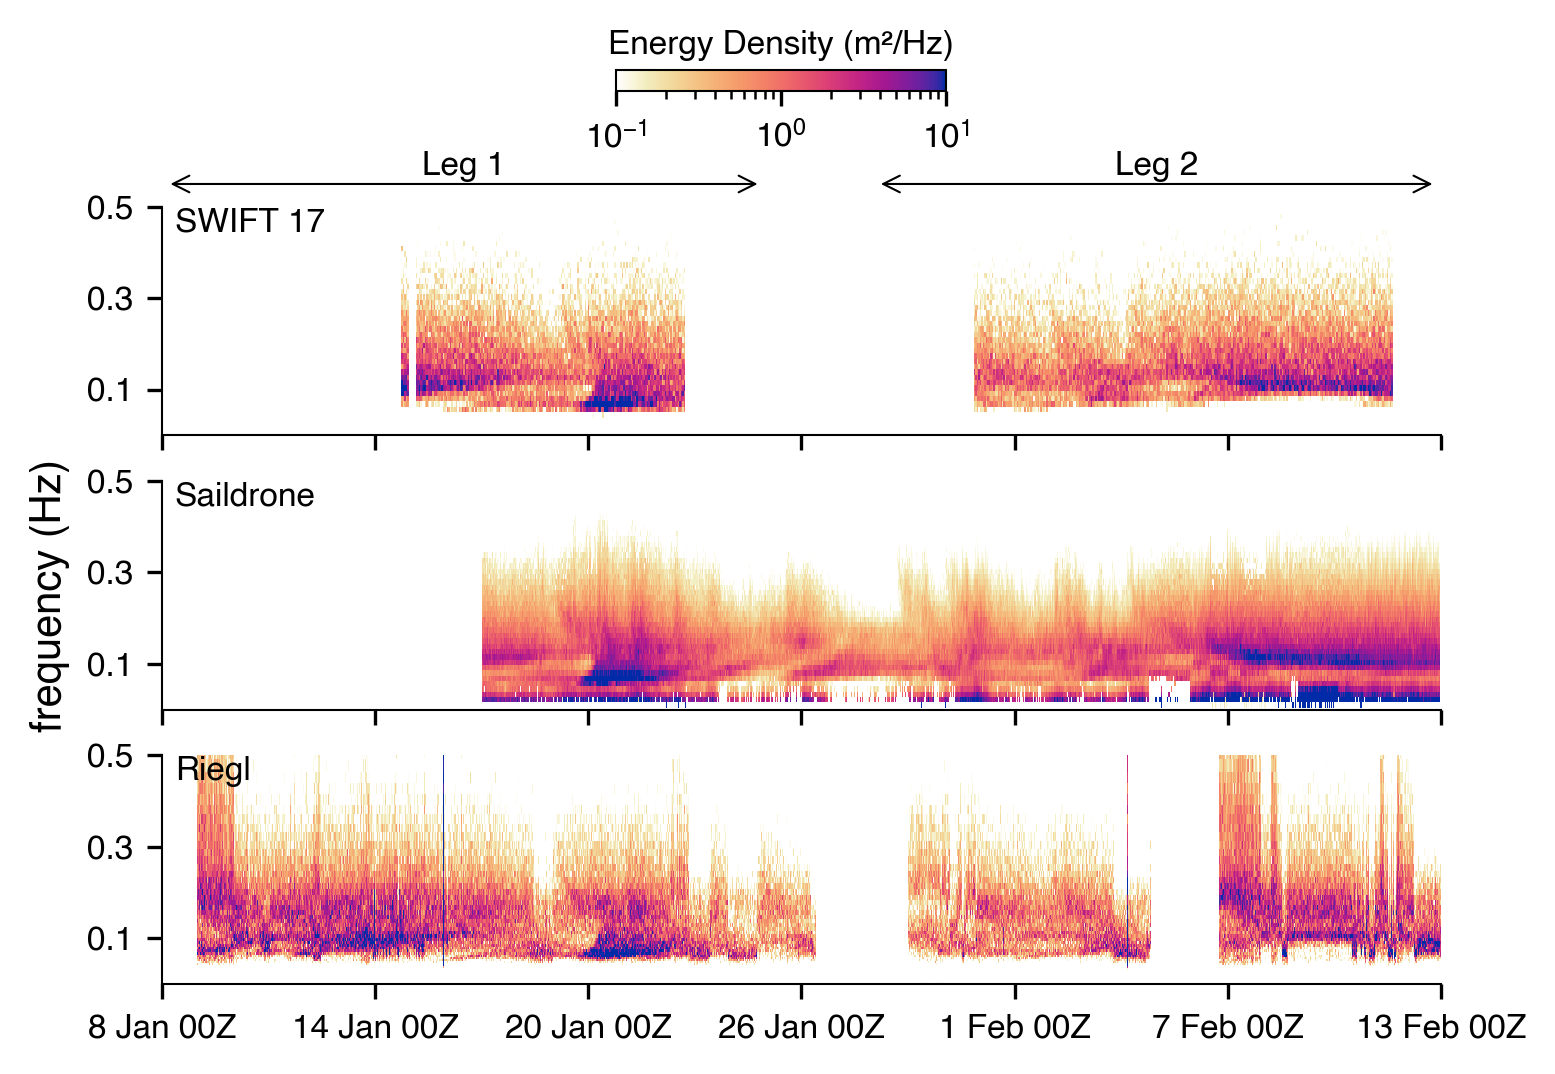

In [8]:
SWIFT_ID = '17'

plot_time_start = pd.Timestamp('2020-01-08T00:00', tz='utc')
plot_time_end = pd.Timestamp('2020-02-13T00:00', tz='utc')
cmap = colorcet.cm.CET_L19
cmap = colorcet.cm.CET_L17
norm = mpl.colors.LogNorm(vmin=10**(-1), vmax=1*10**1)

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    sharex=True,
    sharey=True,
    figsize=(plotting.figure_full_width, 3.5),
)
spec = plotting.spectrogram(
    time=swift_ds['time'].to_numpy(),
    frequency=swift_ds['freq'].to_numpy(),
    spectra=swift_ds.sel(id=SWIFT_ID)['energy'].transpose('time', 'freq').to_numpy(),
    cmap=cmap,
    norm=norm,
    ax=axes[0],
)
_ = plotting.spectrogram(
    time=sd_ds['TIME'].to_numpy(),
    frequency=sd_ds['FRE'].to_numpy(),
    spectra=sd_ds['EI'].transpose('TIME', 'FRE').to_numpy(),
    cmap=cmap,
    norm=norm,
    ax=axes[1],
)
_ = plotting.spectrogram(
    time=riegl_ds['time'].to_numpy(),
    frequency=riegl_ds['frequency'].to_numpy(),
    spectra=riegl_ds['energy_density'].transpose('time', 'frequency').to_numpy(),
    cmap=cmap,
    norm=norm,
    ax=axes[2],
)

annotate_kwargs = dict(
    xy=(0.01, 1),
    ha='left',
    va='top',
    xycoords='axes fraction',
    fontsize=plotting.small_font_size
)
axes[0].annotate(f'SWIFT {SWIFT_ID}', **annotate_kwargs)
axes[1].annotate(f'Saildrone', **annotate_kwargs)
axes[2].annotate(f'Riegl', **annotate_kwargs)


axes[1].set_ylabel('frequency (Hz)', fontsize=plotting.normal_font_size)
axes[-1].set_ylim([0, 0.5])
axes[-1].set_yticks(np.linspace(0.1, 0.5, 3))
plotting.set_time_series_xaxis(axes[0], plot_time_start, plot_time_end, freq='6d', format='%-d %b %HZ')
for ax in axes:
    plotting.remove_top_and_right_spines(ax)

cax = fig.add_axes([0.4, 0.96, 0.2, 0.02])

# Adjust the subplots to make space for the colorbar
fig.subplots_adjust(top=0.85)

fig.colorbar(
    spec,
    cax=cax,
    # ax=axes.ravel().tolist(),
    # location='top',
    orientation='horizontal',
)
cax.set_xlabel('Energy Density (m²/Hz)', fontsize=plotting.small_font_size)
cax.xaxis.set_label_position('top')

plotting.annotate_legs(axes[0], scale=1.1)

# fig.savefig('../atomic_spectrograms.png', dpi=400, bbox_inches='tight')

## Spectral comparisons

In [ ]:
# TODO:

## Mean square slope

TODO:
- [ ] Remove WSRA outliers and low wind speeds (or use different U10)
- [ ] Stability dependence?

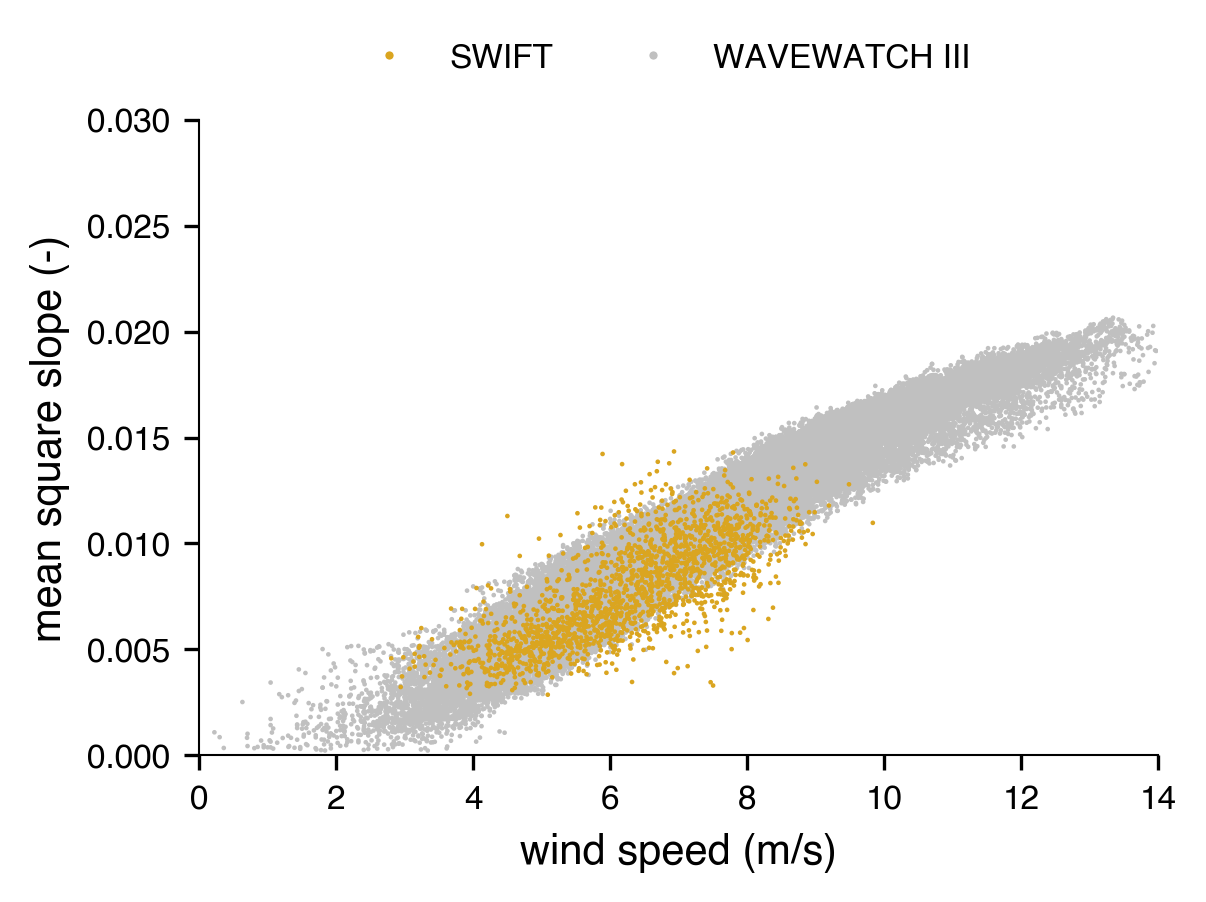

In [ ]:
fig, ax = plt.subplots(
    figsize=(plotting.figure_full_width*3/4, plotting.figure_full_width*1/2)
)

ax.scatter(
    ww3_ds['wnd'],
    ww3_ds['mss'],
    color=ww3_color,
    label='SWIFT',
    **scatter_kwargs,
)
ax.scatter(
    swift_ds['wind_speed'],
    swift_ds['mean_square_slope'],
    color=swift_color,
    label='WAVEWATCH III',
    **scatter_kwargs,
)
# TODO:
# ax.scatter(
#     wsra_ds['wind_speed'],
#     wsra_ds['sea_surface_mean_square_slope_median'],
# )

ax.set_xlabel('wind speed (m/s)')
ax.set_ylabel('mean square slope (-)')
ax.set_xlim(0, 14)
ax.set_ylim(0, 0.03)
plotting.remove_top_and_right_spines(ax)

# Legend
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='SWIFT', markerfacecolor=swift_color),
    plt.Line2D([0], [0], marker='o', color='w', label='WAVEWATCH III', markerfacecolor=ww3_color),
]
fig.legend(
    handles=legend_handles,
    ncols=len(legend_handles),
    loc='lower center',
    bbox_to_anchor=(0.5, 0.9),
    frameon=False,
)

# fig.savefig('../atomic_mean_square_slope_vs_wind_speed.png', dpi=400, bbox_inches='tight')